<a href="https://colab.research.google.com/github/HebaRouk/-Build-a-ML-Workflow-For-Scones-Unlimited-On-Amazon-SageMaker/blob/main/MLproj_(6).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Expresso Churn Prediction

**AI7101 Machine Learning with Python — final project report**

**Team:** Nikolai Nechaev · Sharad Duwal · Heba Qudaih

MBZUAI · October 2026

Expresso, a prepaid telecom operator in Senegal and Mauritania, loses customers without warning: they simply stop topping up. Using the 2.15 million labelled customers of the Zindi *Expresso Churn Prediction* challenge, we build models that estimate each customer's probability of churning, compare them with simple targeting strategies, and estimate what a targeted retention campaign could be worth.

**In short:** we compare three models logistic regression, k-nearest neighbours and gradient-boosted trees (XGBoost). All three rank customers well (validation ROC-AUC 0.926–0.931). The final model, XGBoost, reaches a test ROC-AUC of **0.931**, above a simple rule that contacts the least active customers first (0.89). Turning the ranking into a retention campaign shows that targeting is what makes retention profitable, as long as offers stay cheap. The final results are summarised in the conclusion (Section 6.6).

| Section | Contents |
|---|---|
| 1. Problem statement | What churn is, why it matters, how ML helps |
| 2. Loading the data | `Train.csv`, the variables, inputs `X` and output `y` |
| 3. Data preparation | Removing columns, missing values, new features, split, encoding, scaling |
| 4. Exploratory analysis | Patterns in the data that shape the modelling |
| 5. Validation and models | Cross-validation, metric, three models, tuning, final choice |
| 6. Results and impact | Baselines, business value, sensitivity, findings, real-life use, conclusion |


## 1. Problem statement

### 1.1 What problem are we solving?

**Expresso** is a telecom operator in **Senegal and Mauritania** that sells airtime and mobile data bundles.

A customer **churns** when they become inactive and make **no transactions for 90 days**. Customers buy airtime through top-ups, so there is no contract to cancel: they simply stop topping up and quietly disappear. By the time the company notices, the customer is already gone.

**Goal:** use each customer's behaviour (region, tenure, top-up amount and frequency, revenue, data usage, calls, regularity of activity, and favourite package) to **predict the probability that they will churn**.

**ML formulation**

* **Task:** binary classification, `CHURN = 1` (churned) vs `CHURN = 0` (stayed)
* **Output:** a churn probability between 0 and 1 for every customer
* **Data:** 2,154,048 labelled customers (one row per customer), described by 17 features plus `user_id` and the `CHURN` target
* **Class balance:** 18.75% of customers churned (403,986 customers), so the classes are imbalanced

### 1.2 Why is it important?

* **Lost revenue:** every churner represents a potential loss of future revenue; in our training data alone, 403,986 customers churned.
* **Replacing customers is expensive:** acquiring a new customer can cost 5–25× more than retaining an existing one, and increasing retention by 5% has been reported to increase profits by 25–95% (Harvard Business Review, 2014).
* **Competition:** customers can easily switch operators; our data also records calls to competitor networks such as Orange and Tigo.

### 1.3 How can our ML model help?

* **Early warning:** every customer receives a churn-risk score before they leave.
* **Reduce costs:** retention offers, such as bonus data or discounts, can be directed to customers with the highest predicted risk instead of being offered to everyone.
* **Protect revenue:** for example, retaining 10% of the 403,986 observed churners would correspond to approximately 40,000 customers retained.
* **Increase targeting quality:** loyal customers are not unnecessarily flooded with offers, while the model can highlight behaviours associated with churn.
* **Flexible targeting:** because the model outputs probabilities, Expresso can choose how many customers to contact according to its retention budget.

### 1.4 What does success look like?

A good model ranks customers who are likely to churn above customers who are likely to stay. This allows the company to focus its retention efforts on a relatively small high-risk group while reaching a large share of potential churners.

The Zindi challenge evaluates this ranking quality using **ROC-AUC**. In Section 6, we further translate model performance into estimated business impact.

*References: Zindi, "Expresso Churn Prediction Challenge"; A. Gallo, "The Value of Keeping the Right Customers", Harvard Business Review, 2014.*

## 2. Loading the data

We use `Train.csv` from the Zindi challenge, the dataset containing the known churn outcomes. It contains one row per customer and 19 columns, including the customer identifier, 17 input features, and the `CHURN` target. This labelled dataset is used throughout the project; in Section 3.4, we split 30% of the data into a held-out test set for final evaluation.


In [ ]:
from google.colab import files

print("Upload one ZIP file containing Expresso/Train.csv!")
uploaded = files.upload()
((uploaded_filename, _uploaded_contents),) = uploaded.items()
!unzip "$uploaded_filename"

Upload one ZIP file containing Expresso/Train.csv!


Saving Expresso 1.zip to Expresso 1.zip
Archive:  Expresso 1.zip
   creating: Expresso/
  inflating: Expresso/Train.csv      
  inflating: Expresso/VariableDefinitions.csv  


In [ ]:
# Using the other upload method
!unzip Expresso\ 1.zip

Archive:  Expresso 1.zip
   creating: Expresso/
  inflating: Expresso/Train.csv      
  inflating: Expresso/VariableDefinitions.csv  


In [ ]:
import random
import numpy as np

RANDOM_STATE = 1303

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [ ]:
import pandas as pd

DATA_DIR = "Expresso/"

df = pd.read_csv(DATA_DIR + "Train.csv")
print(df.shape)
df.head()

(2154048, 19)


,user_id,REGION,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,MRG,REGULARITY,TOP_PACK,FREQ_TOP_PACK,CHURN
0,00000bfd7d50f01092811bc0c8d7b0d6fe7c3596,FATICK,K > 24 month,4250.0,15.0,4251.0,1417.0,17.0,4.0,388.0,46.0,1.0,1.0,2.0,NO,54,On net 200F=Unlimited _call24H,8.0,0
1,00000cb4a5d760de88fecb38e2f71b7bec52e834,NaN,I 18-21 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,4,NaN,NaN,1
2,00001654a9d9f96303d9969d0a4a851714a4bb57,NaN,K > 24 month,3600.0,2.0,1020.0,340.0,2.0,NaN,90.0,46.0,7.0,NaN,NaN,NO,17,On-net 1000F=10MilF;10d,1.0,0
3,00001dd6fa45f7ba044bd5d84937be464ce78ac2,DAKAR,K > 24 month,13500.0,15.0,13502.0,4501.0,18.0,43804.0,41.0,102.0,2.0,NaN,NaN,NO,62,"Data:1000F=5GB,7d",11.0,0
4,000028d9e13a595abe061f9b58f3d76ab907850f,DAKAR,K > 24 month,1000.0,1.0,985.0,328.0,1.0,NaN,39.0,24.0,NaN,NaN,NaN,NO,11,Mixt 250F=Unlimited_call24H,2.0,0


### 2.1 The variables

| Column | Meaning (from `VariableDefinitions.csv`) | Type |
|---|---|---|
| `user_id` | customer identifier | text |
| `REGION` | the location of each client | category |
| `TENURE` | duration in the network (bands from 3–6 months to more than 24 months) | ordered category |
| `MONTANT` | top-up amount | number |
| `FREQUENCE_RECH` | number of times the customer refilled | number |
| `REVENUE` | monthly income of each client | number |
| `ARPU_SEGMENT` | income over 90 days / 3 | number |
| `FREQUENCE` | number of times the client has made an income | number |
| `DATA_VOLUME` | number of connections | number |
| `ON_NET` | calls within Expresso | number |
| `ORANGE`, `TIGO` | calls to the competitors Orange and Tigo | number |
| `ZONE1`, `ZONE2` | calls to zones 1 and 2 | number |
| `MRG` | "a client who is going" | category |
| `REGULARITY` | number of times the client is active for 90 days | number |
| `TOP_PACK` | the most active pack | category |
| `FREQ_TOP_PACK` | number of times the client has activated the top pack | number |
| `CHURN` | **target**: 1 = churned, 0 = stayed | binary |

### 2.2 The target: who churned?

In [ ]:
counts = df["CHURN"].value_counts().rename({0: "stayed (0)", 1: "churned (1)"})
pd.DataFrame({"customers": counts, "share (%)": (100 * counts / len(df)).round(2)})

,customers,share (%)
CHURN,,
stayed (0),1750062,81.25
churned (1),403986,18.75


Only 18.75% of customers churned (403,986 of 2,154,048): the classes are imbalanced. This shapes how we split the data (stratified, Section 3.4) and how we measure quality (ROC-AUC, Section 5.2).

### 2.3 Inputs `X` and output `y`
The output `y` is the `CHURN` column; every other column is a candidate input. Section 3 then cleans `X`.

In [ ]:
X = df.drop(columns=["CHURN"])          # inputs: user_id + 17 behavioural features
y = df["CHURN"].astype(int)             # output: 1 = churned, 0 = stayed

print("X:", X.shape, "| y:", y.shape)
print("Missing labels:", int(df["CHURN"].isna().sum()), "| label values:", sorted(y.unique().tolist()))

X: (2154048, 18) | y: (2154048,)
Missing labels: 0 | label values: [0, 1]


### Distribution of REGULARITY
`REGULARITY` counts how many times a customer was active during the 90-day period (from 1 to 62). The statistics below show a wide spread: the median customer was active 24 times, but a quarter of customers were active 6 times or fewer, while another quarter were active 51 times or more. Because churn means 90 days without activity, we expect this variable to be one of the strongest signals; the baseline in Section 6.1 confirms this.


In [ ]:
df['REGULARITY'].describe()

count    2.154048e+06
mean     2.804251e+01
std      2.228686e+01
min      1.000000e+00
25%      6.000000e+00
50%      2.400000e+01
75%      5.100000e+01
max      6.200000e+01
Name: REGULARITY, dtype: float64

### Variable definitions from the data provider
The dataset comes with `VariableDefinitions.csv`, which explains each column. We print it to confirm the meanings summarised in Section 2.1.

In [ ]:
pd.set_option("display.max_colwidth", None)
defs = pd.read_csv(DATA_DIR + "VariableDefinitions.csv")
defs.iloc[2:, [0, 2]]

,Variable Definitions,Unnamed: 2
2,user_id,NaN
3,REGION,the location of each client
4,TENURE,duration in the network
5,MONTANT,top-up amount
6,FREQUENCE_RECH,number of times the customer refilled
7,REVENUE,monthly income of each client
8,ARPU_SEGMENT,income over 90 days / 3
9,FREQUENCE,number of times the client has made an income
10,DATA_VOLUME,number of connections
11,ON_NET,inter expresso call


### Check of the target distribution
Raw counts and percentages of `CHURN`: 1,750,062 customers stayed (81.25%) and 403,986 churned (18.75%). This confirms the class imbalance noted in Section 2.2.

In [ ]:
print(df["CHURN"].value_counts())
print((df["CHURN"].value_counts(normalize=True) * 100).round(2))

CHURN
0    1750062
1     403986
Name: count, dtype: int64
CHURN
0    81.25
1    18.75
Name: proportion, dtype: float64


3. Data preparation

Each step below is motivated by what we see in the data

### 3.1 Remove columns that carry no information
`MRG` has the same value ("NO") for all 2,154,048 customers, so it cannot help separate churners from the others.

In [ ]:
df['MRG'].value_counts() # All "NO", probably drop the column

MRG
NO    2154048
Name: count, dtype: int64

We drop `MRG`, the identifier `user_id` (unique for every customer, it says nothing about behaviour) and `ARPU_SEGMENT` (income over 90 days / 3, practically a copy of `REVENUE`).

In [ ]:
df_ = df.drop(columns=["user_id", "MRG", "ARPU_SEGMENT"]) # ARPU_SEGMENT is dependent on REVENUE

### 3.2 Missing values and tenure
These 11 numeric activity columns have many missing values. Here a missing value means *no recorded activity* (no top-up, calls or data), not a data error.

In [ ]:
COLS = ["MONTANT","FREQUENCE_RECH","REVENUE","FREQUENCE","DATA_VOLUME","ON_NET","ORANGE","TIGO","ZONE1","ZONE2","FREQ_TOP_PACK"]

Missing activity is filled with 0 (no activity). A missing `REGION` becomes its own category "UNKNOWN", because these customers churn far more often (Section 4), and a missing `TOP_PACK` becomes "NO_PACK". `TENURE` bands have a natural order, so we map them to 0–7 ("D 3-6 month" = 0, …, "K > 24 month" = 7).

In [ ]:
TENURE_ORDER = {"D":0,"E":1,"F":2,"G":3,"H":4,"I":5,"J":6,"K":7}

# Fill NaNs with 0 for numerics and "UNKNOWN" for categoricals

df_[COLS] = df_[COLS].fillna(0)
df_["REGION"]   = df_["REGION"].fillna("UNKNOWN")
df_["TOP_PACK"] = df_["TOP_PACK"].fillna("NO_PACK")
df_["TENURE"]   = df_["TENURE"].str[0].map(TENURE_ORDER)

### 3.3 New features
We add three features that describe *how* a customer uses the service, not only how much:
- **`REV_PER_RECH`** = `REVENUE` / (`FREQUENCE_RECH` + 1): the average revenue per top-up. A customer who tops up often but spends little each time behaves differently from one who makes a few large top-ups. The +1 avoids dividing by zero for customers with no top-ups.
- **`ONNET_SHARE`** = `ON_NET` / (`ON_NET` + `ORANGE` + `TIGO` + 1): the share of calls that stay inside the Expresso network. A customer who mostly calls Orange or Tigo numbers may find it easier to switch operator.
- **`DATA_USER`** = 1 if the customer used mobile data (`DATA_VOLUME` > 0), otherwise 0. Customers who use data may be more attached to the service.

All three are computed after the missing values were filled with 0, so a customer with no recorded activity gets 0 for each of them.

In [ ]:
# The features that we tried adding and training on, but they didn't add any value!

# df_["REV_PER_RECH"] = df_["REVENUE"] / (df_["FREQUENCE_RECH"] + 1)
# df_["ONNET_SHARE"]  = df_["ON_NET"] / (df_["ON_NET"] + df_["ORANGE"] + df_["TIGO"] + 1)
# df_["DATA_USER"]    = (df_["DATA_VOLUME"] > 0).astype(int)

### Categorical columns
`REGION` and `TOP_PACK` are nominal categories: there is no natural order between two regions (e.g. Dakar and Thiès) or between two packages. Models need numbers, so after the train/test split these columns are one-hot encoded (Section 3.5): each value becomes its own 0/1 column.

`TENURE` is not in this list. We also considered treating it as a category (the commented line), but its bands have a natural order, so we keep it as the single ordered number 0–7 from Section 3.2 instead of eight separate columns.

In [ ]:
cat_cols = ["REGION", "TOP_PACK"]
# cat_cols = ["REGION", "TOP_PACK", "TENURE"]

### 3.4 Train/test split and rare packages
`X` contains all remaining input columns and `y` is the `CHURN` target, converted to integers (1 = churned, 0 = stayed).

We keep **30% of the customers (646,215) aside as a test set**. It is used only once, at the end, to measure the final quality on customers no model has seen. All choices models, hyperparameters, features are made with cross-validation on the remaining **70% training set (1,507,833 customers)**.
- **`stratify=y`** keeps the same churn rate (18.75%) in both parts. With imbalanced classes, a purely random split could give the two parts slightly different churn rates and distort the comparison.
- **`random_state=1303`** makes the split reproducible: every run, and every team member, gets exactly the same training and test customers.

**Grouping rare packages.** `TOP_PACK` has 134 different packages in the training set, and most of them are used by very few customers. One-hot encoding all of them would add many sparse, noisy columns. We therefore keep the 15 most frequent packages (together they cover about 93% of the training customers, including "NO_PACK") and group the rest as "OTHER". The list is chosen on the training set only and then applied to the test set, so no information from the test customers leaks into the preparation.

In [ ]:
from sklearn.model_selection import train_test_split

X = df_.drop(columns=["CHURN"])
y = df_["CHURN"].astype(int) # converted to int as needed by training

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.3, stratify=y, random_state=1303)

top_packs = X_train["TOP_PACK"].value_counts().head(15).index
for d in (X_train, X_test):
  d["TOP_PACK"] = d["TOP_PACK"].where(d["TOP_PACK"].isin(top_packs), "OTHER")

### 3.5 Encoding, scaling and a first model
**One-hot encoding.** The encoder is fitted on the training set only and then applied to both sets: every region and every package group becomes its own 0/1 column. `handle_unknown="ignore"` turns a category never seen in training into all zeros instead of an error.

**Standardisation.** Logistic regression (through its penalty) and KNN (through its distances) are sensitive to the scale of the inputs: `DATA_VOLUME` can reach tens of thousands, while `TENURE` stays between 0 and 7. We therefore rescale the 11 activity columns, `TENURE` and `REGULARITY` to mean 0 and standard deviation 1, using means and deviations computed on the training set only, so no information from the test set leaks in.

**A first model as a sanity check.** Before any tuning, a plain logistic regression already reaches a **test ROC-AUC of 0.9275**: the prepared features clearly carry signal. The other numbers show why accuracy is not our main metric:
- **Accuracy 0.873** looks good, but a model that always predicts "stays" already scores 81.25%.
- At the default 0.5 threshold, the model catches **75.1% of the churners** (recall), and **63.7%** of the customers it flags really churn (precision). Moving the threshold trades one for the other, so in Section 5 we compare models with ROC-AUC, which does not depend on any threshold.

*The `ConvergenceWarning` above means the solver stopped at its iteration limit, most likely because the new feature `REV_PER_RECH` is not standardised.*

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32).fit(X_train[cat_cols])

def apply_ohe(d):
  enc = pd.DataFrame(ohe.transform(d[cat_cols]), columns=ohe.get_feature_names_out(cat_cols), index=d.index)
  return pd.concat([d.drop(columns=cat_cols), enc], axis=1)

X_train, X_test = apply_ohe(X_train), apply_ohe(X_test)

num_cols = COLS + ["TENURE", "REGULARITY"]
# num_cols = COLS + ["REGULARITY"] #+ (["N_MISSING"] if use_flags else [])
scaler = StandardScaler().fit(X_train[num_cols])
X_train[num_cols] = scaler.transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# Baseline logistic regression
clf = LogisticRegression(max_iter=1000).fit(X_train, y_train)
%time proba = clf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("acc", round(accuracy_score(y_test, pred), 4))
print("F1", round(f1_score(y_test, pred), 4))
print("ROC-AUC", round(roc_auc_score(y_test, proba), 4))

print(classification_report(y_test, pred, digits=3))

CPU times: user 1.24 s, sys: 14.9 ms, total: 1.25 s
Wall time: 85.7 ms
acc 0.8725
F1 0.6884
ROC-AUC 0.9268
              precision    recall  f1-score   support

           0      0.940     0.901     0.920    525019
           1      0.636     0.751     0.688    121196

    accuracy                          0.873    646215
   macro avg      0.788     0.826     0.804    646215
weighted avg      0.883     0.873     0.876    646215



## 4. Exploratory analysis
We use Seaborn plots to look for patterns that can guide the modelling. Each plot below answers one question:
1. How imbalanced is the target?
2. Does missing activity tell us something about churn?
3. Does churn depend on the region?
4. Does churn depend on how long the customer has been on the network?

The answers support the preparation choices of Section 3 (keeping missing values as information, a separate "UNKNOWN" region) and guide the choice of metric and models in Section 5.

### 4.1 How imbalanced is the target?
The bar chart counts customers by outcome (the y-axis is in millions): about 1.75M customers stayed (`CHURN = 0`, 81.25%) and about 0.40M churned (`CHURN = 1`, 18.75%).

This imbalance has two consequences. First, accuracy is misleading: a model that always predicts "stays" is already 81% accurate while catching no churner, so we judge models by ROC-AUC instead (Section 5). Second, we use a stratified train/test split (Section 3.4) and stratified cross-validation folds, so that every part keeps the same 18.75% churn rate.

<Axes: xlabel='CHURN', ylabel='count'>

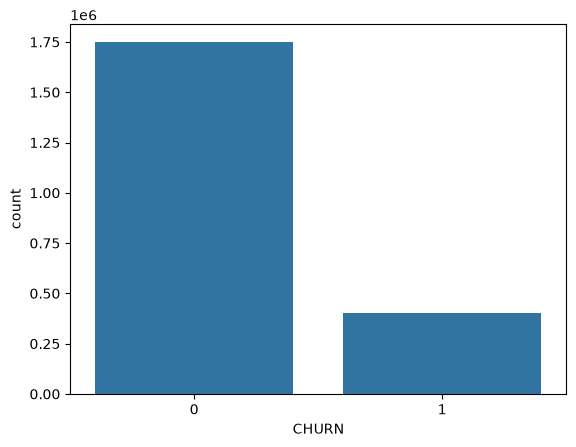

In [ ]:
import seaborn as sns

sns.countplot(x="CHURN", data=df_)

### 4.2 Does missing activity tell us something about churn?
We split customers into two groups: those with a complete activity record (`False`: none of the 11 activity columns is missing) and those with at least one missing value (`True`), and plot the churn rate of each group.

Customers with a complete record almost never churn (about 2%), while the rest churn at about 19%. Note that almost every customer falls in the `True` group, because `ZONE1` and `ZONE2` are missing for more than 90% of customers; this is why the right bar is close to the overall churn rate. The black lines are 95% confidence intervals: the left bar covers few customers, so its interval is wider.

The conclusion is that a missing value is not random noise: it marks less active customers, who churn more. This supports our choice in Section 3.2 to keep these customers and fill missing activity with 0, instead of dropping the rows.

<Axes: xlabel='None', ylabel='CHURN'>

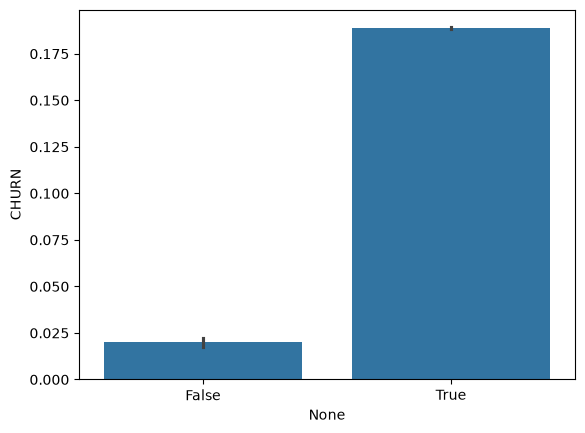

In [ ]:
miss = df[COLS].isna().mean(axis=1).gt(0)
sns.barplot(x=miss, y=df["CHURN"].astype(int))

### 4.3 Does churn depend on the region?
The plot shows the churn rate (the mean of `CHURN`) for each region, sorted from lowest to highest.

Every known region has a low churn rate, between about 1% (Kaffrine) and 4% (Sedhiou, Kédougou). Customers whose region is missing ("UNKNOWN") churn at about 45%, more than ten times as often. So the region itself matters little, but *not knowing* the region matters a lot: a missing region is another sign of an inactive customer. This is why we kept "UNKNOWN" as its own category in Section 3.2 instead of filling it with the most common region.

<Axes: xlabel='mean', ylabel='REGION'>

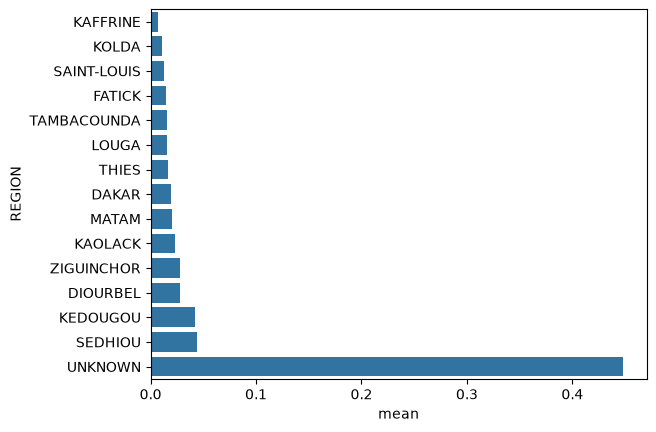

In [ ]:
r = df_.groupby("REGION")["CHURN"].agg(["mean","size"]).sort_values("mean")
sns.barplot(x=r["mean"], y=r.index)

### 4.4 Does churn depend on time on the network?
The x-axis is the ordered tenure band from Section 3.2 (0 = 3–6 months, 3 = 12–15 months, 7 = more than 24 months), and the bars show the churn rate in each band.

Churn is not monotonic in tenure. It rises from about 15% for the newest customers to a peak of about 32% at 12–15 months, then falls to about 18% for customers with more than 24 months. The shorter bands contain far fewer customers, since most customers have been on the network for more than 24 months.

This shape matters for model choice: a linear model gives `TENURE` a single coefficient, so it can only learn a steadily rising or falling effect and will miss the peak. This is one reason we also try non-linear models, KNN and gradient-boosted trees (XGBoost), in Section 5.

<Axes: xlabel='TENURE', ylabel='mean'>

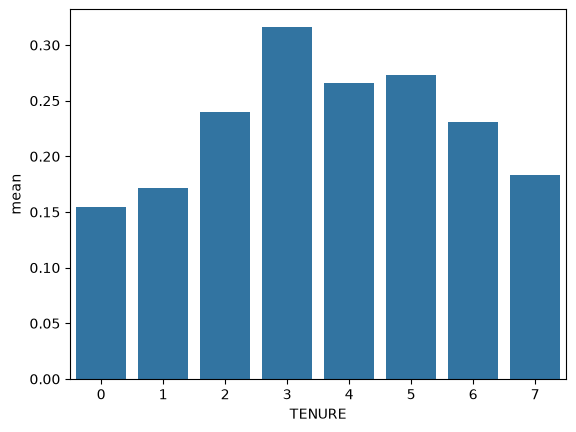

In [ ]:
r = df_.groupby("TENURE")["CHURN"].agg(["mean", "size"])
sns.barplot(x=r.index, y=r["mean"])

### 4.5 What the exploration tells us
| Finding | What we do with it |
|---|---|
| Only 18.75% of customers churn (4.1) | Stratified split and folds; ROC-AUC instead of accuracy (Section 5) |
| Missing activity marks inactive customers, who churn more (4.2) | Keep these rows and fill missing activity with 0 (3.2) |
| A missing region means about 45% churn, vs 1–4% for known regions (4.3) | Keep "UNKNOWN" as its own category (3.2) |
| Churn peaks at 12–15 months of tenure (4.4) | The effect is not linear, so we also try KNN and XGBoost (Section 5) |

## 5. Validation and model selection

### 5.1 Cross-validation procedure
- **Stratified 5-fold cross-validation on the training set (1,507,833 customers).** With its default `cv`, `GridSearchCV` uses 5 stratified folds for classifiers: each model is trained on four folds and scored on the fifth, five times, and we average the five scores. Stratification keeps the 18.75% churn rate in every fold, which matters for an imbalanced target.
- **Why 5 folds?** Each validation fold still holds about 300,000 customers, so the score barely changes from fold to fold (standard deviation ≈ 0.0002, see the results below). More folds would multiply the run time, which is already hours for KNN, without making the estimate more reliable.
- **The test set (646,215 customers) is used only once**, to report the final quality of each tuned model.

### 5.2 Quality measure: ROC-AUC
ROC-AUC is the probability that a randomly chosen churner gets a higher risk score than a randomly chosen customer who stays: 0.5 means random guessing, 1.0 a perfect ranking.
- **It fits our data:** with only 18.75% churners, accuracy is misleading. A model that always predicts "stays" is 81% accurate, but its ROC-AUC is only 0.5.
- **It fits how the model will be used:** Expresso will rank customers by risk and contact as many as its budget allows. ROC-AUC measures exactly this ranking, without fixing a decision threshold.
- **It is the official metric** of the Zindi challenge.

ROC-AUC must be computed from predicted probabilities (`predict_proba`), not from 0/1 predictions (`predict`). The cell below confirms the sizes of the training and test sets.

The training set has 1,507,833 customers (70%) and the test set 646,215 (30%), with one `CHURN` label per customer. The second number is the number of input columns after one-hot encoding: 44 = 13 numeric columns (the 11 activity columns, `TENURE` and `REGULARITY`) + 15 region columns (14 regions and "UNKNOWN") + 16 package columns (the 15 most frequent packages and "OTHER").

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1507833, 44)
(646215, 44)
(1507833,)
(646215,)


### An experiment we did not keep The threshold only matters later, when Expresso decides how many customers to contact (Section 6). a custom decision threshold
This helper class wraps `LogisticRegression` to test decision thresholds other than the default 0.5. `fit` trains the usual model, and `predict` turns the predicted probabilities into 0/1 labels using an adjustable `threshold`. `score` deliberately raises an error, so that a grid search cannot silently fall back to accuracy as its scoring rule.

The class is **not used in the final results** (the grid search line that used it is commented out below). We dropped the idea because our quality measure, ROC-AUC, is computed from the predicted probabilities and does not depend on any threshold. The threshold only matters later, when

In [ ]:
# TODO: remove?
class ThresholdedBinaryLogistic(object):
  def __init__(self, solver, threshold=0.5):
    self.regressor = LogisticRegression(solver=solver)
    self.threshold = threshold

  def __getattr__(self, attr):
    assert id(object.__getattribute__(self, 'regressor'))
    return self.regressor.__getattribute__(attr)

  def __setattr__(self, attr, val):
    if attr in ('regressor', 'threshold'):
      return object.__setattr__(self, attr, val)
    return self.regressor.__setattr__(attr, val)

  def fit(self, X, y):
    return self.regressor.fit(X, y)

  def predict(self, X):
    print(self.threshold)
    proba0 = self.regressor.predict_proba(X)[:, 0]
    return (proba0 >= self.threshold).astype(int)

  def score(self, X, y):
    raise RuntimeError()

  def scorer_(self, X, y):
    raise RuntimeError()

### 5.3 Model 1: logistic regression
Logistic regression is a linear model of the log-odds of churning. It is fast, hard to overfit with 1.5M training customers, and easy to interpret through its coefficients, so it is a natural first model.

**Hyperparameters.** We tune the regularisation penalty: none, L1 or L2. No single solver here supports all three: `lbfgs` handles none and L2, while `liblinear` handles L1 and L2. The grid therefore tries both solvers. The two invalid combinations (lbfgs + L1, liblinear + none) fail by design and appear as `nan` in the results; this is expected, not an error.

**Result.** All valid settings reach a cross-validated ROC-AUC of about 0.926, and they differ only in the fifth decimal. The penalty has no real effect, because with 1.5M customers and only a few dozen features there is no overfitting to control. The best setting is L2 with `liblinear`, while `lbfgs` with L2 trains several times faster (see the fit times in the log).

In [ ]:
# Model 1: Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline

param_grid = {
    'logisticregression__penalty': [None, 'l1', 'l2'],
    'logisticregression__solver': ['lbfgs', 'liblinear'],
}

grid_logreg = GridSearchCV(make_pipeline(LogisticRegression()), param_grid, cv=None, scoring='roc_auc', verbose=10)
# grid = GridSearchCV(make_pipeline(ThresholdedBinaryLogistic(solver='liblinear', threshold=0.8)), param_grid, cv=2, scoring='roc_auc', verbose=10)

grid_logreg.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV 1/5; 1/6] START logisticregression__penalty=None, logisticregression__solver=lbfgs


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV 1/5; 1/6] END logisticregression__penalty=None, logisticregression__solver=lbfgs;, score=0.926 total time=   5.0s
[CV 2/5; 1/6] START logisticregression__penalty=None, logisticregression__solver=lbfgs


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV 2/5; 1/6] END logisticregression__penalty=None, logisticregression__solver=lbfgs;, score=0.926 total time=   7.5s
[CV 3/5; 1/6] START logisticregression__penalty=None, logisticregression__solver=lbfgs


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV 3/5; 1/6] END logisticregression__penalty=None, logisticregression__solver=lbfgs;, score=0.926 total time=   4.7s
[CV 4/5; 1/6] START logisticregression__penalty=None, logisticregression__solver=lbfgs


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV 4/5; 1/6] END logisticregression__penalty=None, logisticregression__solver=lbfgs;, score=0.926 total time=   5.3s
[CV 5/5; 1/6] START logisticregression__penalty=None, logisticregression__solver=lbfgs


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV 5/5; 1/6] END logisticregression__penalty=None, logisticregression__solver=lbfgs;, score=0.926 total time=   5.8s
[CV 1/5; 2/6] START logisticregression__penalty=None, logisticregression__solver=liblinear
[CV 1/5; 2/6] END logisticregression__penalty=None, logisticregression__solver=liblinear;, score=nan total time=   0.1s
[CV 2/5; 2/6] START logisticregression__penalty=None, logisticregression__solver=liblinear


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV 2/5; 2/6] END logisticregression__penalty=None, logisticregression__solver=liblinear;, score=nan total time=   0.1s
[CV 3/5; 2/6] START logisticregression__penalty=None, logisticregression__solver=liblinear
[CV 3/5; 2/6] END logisticregression__penalty=None, logisticregression__solver=liblinear;, score=nan total time=   0.1s
[CV 4/5; 2/6] START logisticregression__penalty=None, logisticregression__solver=liblinear


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV 4/5; 2/6] END logisticregression__penalty=None, logisticregression__solver=liblinear;, score=nan total time=   0.1s
[CV 5/5; 2/6] START logisticregression__penalty=None, logisticregression__solver=liblinear
[CV 5/5; 2/6] END logisticregression__penalty=None, logisticregression__solver=liblinear;, score=nan total time=   0.1s
[CV 1/5; 3/6] START logisticregression__penalty=l1, logisticregression__solver=lbfgs


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV 1/5; 3/6] END logisticregression__penalty=l1, logisticregression__solver=lbfgs;, score=nan total time=   0.1s
[CV 2/5; 3/6] START logisticregression__penalty=l1, logisticregression__solver=lbfgs
[CV 2/5; 3/6] END logisticregression__penalty=l1, logisticregression__solver=lbfgs;, score=nan total time=   0.1s
[CV 3/5; 3/6] START logisticregression__penalty=l1, logisticregression__solver=lbfgs


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV 3/5; 3/6] END logisticregression__penalty=l1, logisticregression__solver=lbfgs;, score=nan total time=   0.1s
[CV 4/5; 3/6] START logisticregression__penalty=l1, logisticregression__solver=lbfgs
[CV 4/5; 3/6] END logisticregression__penalty=l1, logisticregression__solver=lbfgs;, score=nan total time=   0.1s
[CV 5/5; 3/6] START logisticregression__penalty=l1, logisticregression__solver=lbfgs


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV 5/5; 3/6] END logisticregression__penalty=l1, logisticregression__solver=lbfgs;, score=nan total time=   0.1s
[CV 1/5; 4/6] START logisticregression__penalty=l1, logisticregression__solver=liblinear


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[CV 1/5; 4/6] END logisticregression__penalty=l1, logisticregression__solver=liblinear;, score=0.926 total time=  11.2s
[CV 2/5; 4/6] START logisticregression__penalty=l1, logisticregression__solver=liblinear


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[CV 2/5; 4/6] END logisticregression__penalty=l1, logisticregression__solver=liblinear;, score=0.926 total time=  13.7s
[CV 3/5; 4/6] START logisticregression__penalty=l1, logisticregression__solver=liblinear


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[CV 3/5; 4/6] END logisticregression__penalty=l1, logisticregression__solver=liblinear;, score=0.926 total time=  13.9s
[CV 4/5; 4/6] START logisticregression__penalty=l1, logisticregression__solver=liblinear


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[CV 4/5; 4/6] END logisticregression__penalty=l1, logisticregression__solver=liblinear;, score=0.926 total time=  12.4s
[CV 5/5; 4/6] START logisticregression__penalty=l1, logisticregression__solver=liblinear


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[CV 5/5; 4/6] END logisticregression__penalty=l1, logisticregression__solver=liblinear;, score=0.927 total time=  10.5s
[CV 1/5; 5/6] START logisticregression__penalty=l2, logisticregression__solver=lbfgs


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV 1/5; 5/6] END logisticregression__penalty=l2, logisticregression__solver=lbfgs;, score=0.926 total time=   5.6s
[CV 2/5; 5/6] START logisticregression__penalty=l2, logisticregression__solver=lbfgs


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV 2/5; 5/6] END logisticregression__penalty=l2, logisticregression__solver=lbfgs;, score=0.926 total time=   5.4s
[CV 3/5; 5/6] START logisticregression__penalty=l2, logisticregression__solver=lbfgs


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV 3/5; 5/6] END logisticregression__penalty=l2, logisticregression__solver=lbfgs;, score=0.926 total time=   5.5s
[CV 4/5; 5/6] START logisticregression__penalty=l2, logisticregression__solver=lbfgs


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV 4/5; 5/6] END logisticregression__penalty=l2, logisticregression__solver=lbfgs;, score=0.926 total time=   5.7s
[CV 5/5; 5/6] START logisticregression__penalty=l2, logisticregression__solver=lbfgs


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV 5/5; 5/6] END logisticregression__penalty=l2, logisticregression__solver=lbfgs;, score=0.926 total time=   4.0s
[CV 1/5; 6/6] START logisticregression__penalty=l2, logisticregression__solver=liblinear


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV 1/5; 6/6] END logisticregression__penalty=l2, logisticregression__solver=liblinear;, score=0.926 total time=   8.4s
[CV 2/5; 6/6] START logisticregression__penalty=l2, logisticregression__solver=liblinear


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV 2/5; 6/6] END logisticregression__penalty=l2, logisticregression__solver=liblinear;, score=0.926 total time=   8.1s
[CV 3/5; 6/6] START logisticregression__penalty=l2, logisticregression__solver=liblinear


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV 3/5; 6/6] END logisticregression__penalty=l2, logisticregression__solver=liblinear;, score=0.926 total time=   8.0s
[CV 4/5; 6/6] START logisticregression__penalty=l2, logisticregression__solver=liblinear


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV 4/5; 6/6] END logisticregression__penalty=l2, logisticregression__solver=liblinear;, score=0.926 total time=   8.6s
[CV 5/5; 6/6] START logisticregression__penalty=l2, logisticregression__solver=liblinear


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV 5/5; 6/6] END logisticregression__penalty=l2, logisticregression__solver=liblinear;, score=0.927 total time=   8.0s


/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:489: FitFailedWarning: 
10 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/site-packages/sklearn/base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/nikolai/.conda/envs/ml-lab1/lib/python3.11/sit

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'logisticregression__penalty': [None, 'l1', ...], 'logisticregression__solver': ['lbfgs', 'liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, 

### Logistic regression on the test set
The best setting found by cross-validation is the L2 penalty with the `liblinear` solver, with a cross-validated ROC-AUC of 0.92615.

**Note on the test ROC-AUC printed below (0.8257).** This value is computed from the 0/1 labels returned by `predict`, not from probabilities. With only two possible scores, the ranking between customers is lost, and ROC-AUC reduces to the balanced accuracy at the 0.5 threshold: the average of the recall of churners and the recall of customers who stay. This is the same 0.826 as the "macro avg" recall in the classification report of Section 3.5. Computed from the predicted probabilities (`predict_proba`), as in Section 3.5, the test ROC-AUC of logistic regression is about 0.927, in line with its cross-validated score.

Prediction is very fast (a fraction of a second for 646,215 customers), and test accuracy at the 0.5 threshold is 0.873.

In [ ]:
from sklearn.metrics import roc_auc_score

best_logreg = grid_logreg.best_estimator_
print("best params :", grid_logreg.best_params_)
print("best score  :", grid_logreg.best_score_)
%time y_pred = best_logreg.predict(X_test)
y_predict_proba = best_logreg.predict_proba(X_test)
print("test ROC AUC:", round(roc_auc_score(y_test, y_predict_proba[:,1]), 4))
print("FYI,test acc:", round(accuracy_score(y_test, y_pred), 4))

best params : {'logisticregression__penalty': 'l2', 'logisticregression__solver': 'liblinear'}
best score  : 0.9261549938790733
CPU times: user 251 ms, sys: 8.93 ms, total: 260 ms
Wall time: 60.1 ms
test ROC AUC: 0.9267
FYI,test acc: 0.8726


### Cross-validation details and confusion matrix
The first two lines list the mean and the standard deviation of the cross-validated ROC-AUC for the six combinations of penalty and solver, in this order: (none, lbfgs), (none, liblinear), (L1, lbfgs), (L1, liblinear), (L2, lbfgs), (L2, liblinear). The two `nan` values are the invalid combinations. The four valid settings are within 0.00002 of each other, while the scores vary by about 0.0002 from fold to fold. The differences between penalties are therefore much smaller than the noise, which confirms that the penalty does not matter here.

The confusion matrix shows the test customers at the default 0.5 threshold:
- **90,980 churners are caught** (true positives) and **30,216 are missed** (false negatives, shown as "3e+04"), so the model catches **75.1% of the churners** (recall).
- **52,133 loyal customers are wrongly flagged** (false positives). Of all flagged customers, **63.6% really churn** (precision).
- **472,886 loyal customers are correctly left alone**, i.e. 90.1% of them.

In a retention campaign, the false positives are customers who would receive an offer they did not need. Each one costs money, which is why Section 6 weighs the cost of an offer against the value of a saved customer.

The average of the two recalls, (75.1% + 90.1%) / 2 ≈ 0.826, is exactly the "test ROC AUC" printed above, which confirms that this value was computed from 0/1 predictions rather than probabilities.

Mean test score: [0.9261351         nan        nan 0.92615411 0.92613143 0.92615499]
Std test score: [0.00019693        nan        nan 0.00020165 0.00019672 0.00020198]


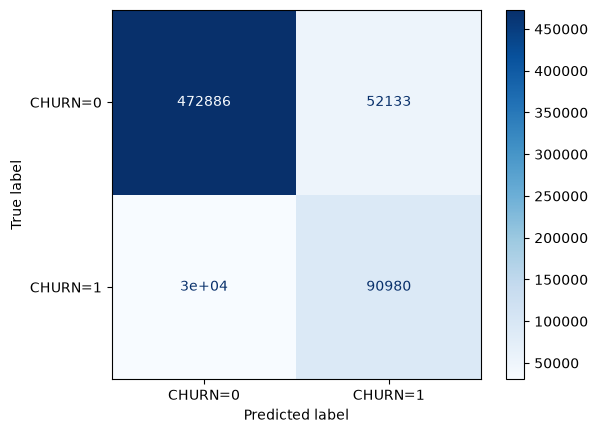

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

mean_test_score = grid_logreg.cv_results_['mean_test_score']
std_test_score = grid_logreg.cv_results_['std_test_score']
print('Mean test score:', mean_test_score)
print('Std test score:', std_test_score)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['CHURN=0', 'CHURN=1']).plot(cmap='Blues')
plt.show()

### 5.4 Model 2: k-nearest neighbours (KNN)
KNN predicts a customer's churn probability as the share of churners among the *k* most similar training customers. Unlike logistic regression, it makes no linearity assumption, so it can capture patterns such as the churn peak at 12–15 months of tenure (Section 4.4). Because it relies on distances, all inputs are standardised first (the `StandardScaler` in the pipeline); otherwise large-valued columns such as `DATA_VOLUME` would dominate the distance.

**Hyperparameter: the number of neighbours k.** A small k bases each estimate on few neighbours, so it is noisy. A large k gives smoother estimates but can blur real differences between customers. A first, quicker 2-fold search with k = 5, 40 and 100 showed that small k scores worse (about 0.89 for k = 5). The 5-fold search below therefore tries larger values: k = 50, 100, 200, 300, 400 and 500.

**Result.** The cross-validated ROC-AUC rises from 0.9258 (k = 50) to **0.9288 (k = 300)** and then levels off, so k = 300 is chosen. This is slightly better than logistic regression (0.9262): the non-linear model finds a little more signal.

**Cost.** KNN is by far the slowest model. Each cross-validation fit takes about 5 minutes (30 fits, about 2.5 hours in total), and predicting the 646,215 test customers takes about 12 minutes, against a fraction of a second for logistic regression. KNN must also keep all 1.5M training customers in memory, and it cannot explain why a customer is at risk.

**How to read the log below.** The search runs 6 values of k × 5 folds = 30 fits. Each `END` line shows the ROC-AUC on one validation fold and the time of that fit (about 5 minutes). At the end, the cell prints the best k, its mean cross-validated ROC-AUC (0.9288) and the test accuracy at the 0.5 threshold (0.8793). That accuracy is slightly higher than logistic regression's (0.8726), but as explained in Section 5.2, accuracy is not our main measure.

We then test the K Nearest Neighbors classifier, after performing standard scaling of the input data. We perform cross-validation on the number of neighbors hyperparameter: we try values 50, 100, 200, 300, 400, 500.

The fold of size 300 achieves the best value of cross-validation score, $\approx0.929$, which is better than that of logistic regression, $\approx0.926$. However, the test error is found to be worse: $\approx0.788$ for KNN and $\approx0.826$ for logistic regression.

Notably, the KNN model also takes much longer to compute, for both fitting and prediction stage (see measurements below).

**How to read the log below.** The search runs 6 values of k × 5 folds = 30 fits. Each `END` line shows the ROC-AUC on one validation fold and the time of that fit (about 5 minutes). At the end, the cell prints the best k, its mean cross-validated ROC-AUC (0.9288) and the test accuracy at the 0.5 threshold (0.8793). That accuracy is slightly higher than logistic regression's (0.8726), but as explained in Section 5.2, accuracy is not our main measure.

In [ ]:
# Model 2: KNN classifier

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    'kneighborsclassifier__n_neighbors': [500, 400, 300, 200, 100, 50],
}

grid = GridSearchCV(make_pipeline(StandardScaler(), KNeighborsClassifier()), param_grid, cv=None, scoring='roc_auc', verbose=10)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV 1/5; 1/6] START kneighborsclassifier__n_neighbors=500.......................
[CV 1/5; 1/6] END kneighborsclassifier__n_neighbors=500;, score=0.929 total time= 5.1min
[CV 2/5; 1/6] START kneighborsclassifier__n_neighbors=500.......................
[CV 2/5; 1/6] END kneighborsclassifier__n_neighbors=500;, score=0.929 total time= 5.1min
[CV 3/5; 1/6] START kneighborsclassifier__n_neighbors=500.......................
[CV 3/5; 1/6] END kneighborsclassifier__n_neighbors=500;, score=0.929 total time= 5.1min
[CV 4/5; 1/6] START kneighborsclassifier__n_neighbors=500.......................
[CV 4/5; 1/6] END kneighborsclassifier__n_neighbors=500;, score=0.929 total time= 5.1min
[CV 5/5; 1/6] START kneighborsclassifier__n_neighbors=500.......................
[CV 5/5; 1/6] END kneighborsclassifier__n_neighbors=500;, score=0.929 total time= 5.1min
[CV 1/5; 2/6] START kneighborsclassifier__n_neighbors=400.......................
[CV 1/5; 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'kneighborsclassifier__n_neighbors': [500, 400, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother case

### KNN on the test set
The search selects **k = 300**, with a cross-validated ROC-AUC of 0.9288.

**Prediction cost.** Predicting the 646,215 test customers took 12 minutes of wall time but about 1 h 35 min of CPU time: the work was spread over about 8 processor cores, because every prediction compares one customer with all 1.5M training customers. Scoring the whole base of 2.15M customers would take about 40 minutes on the same machine, against a fraction of a second for logistic regression. This makes KNN impractical for regular scoring, even though it ranks customers well.

**Quality.** The printed "test ROC AUC" (0.7875) is computed from 0/1 predictions, so it is the balanced accuracy at the 0.5 threshold, not a ROC-AUC (see the note in the logistic regression test cell). It is lower than logistic regression's 0.8257 even though KNN's accuracy is higher (0.879 vs 0.873). The reason is that at the 0.5 threshold KNN is more cautious: it flags fewer customers, so it misses more churners but raises fewer false alarms (see the confusion matrix below). Computed from probabilities on a sample of 50,000 test customers, KNN's test ROC-AUC is 0.928, in line with its cross-validated score.

In [ ]:
from sklearn.metrics import roc_auc_score

best_knn = grid.best_estimator_

print("best params :", grid.best_params_)
print("best score  :", grid.best_score_)
%time y_proba = best_knn.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

print("test ROC AUC:", round(roc_auc_score(y_test, y_pred), 4))
print("FYI,test acc:", round(accuracy_score(y_test, y_pred), 4))

best params : {'kneighborsclassifier__n_neighbors': 300}
best score  : 0.9288208915574163
CPU times: user 1h 42min 11s, sys: 3.86 s, total: 1h 42min 14s
Wall time: 13min 6s
test ROC AUC: 0.7938
FYI,test acc: 0.8787


### KNN: cross-validation details and confusion matrix
The first two lines list the mean and the standard deviation of the cross-validated ROC-AUC for k = 500, 400, 300, 200, 100 and 50, in the order of the grid. The score is flat between k = 200 and k = 500 (0.9287–0.9288) and drops for smaller k (0.9258 at k = 50). k = 50 also has the largest spread across folds (0.0007), because with fewer neighbours the estimates are noisier.

The confusion matrix shows the test customers at the 0.5 threshold:
- **77,644 churners are caught** and **43,552 are missed**, so KNN catches **64.1% of the churners** (logistic regression: 75.1%).
- **34,417 loyal customers are wrongly flagged** (logistic regression: 52,133), so **69.3% of the flagged customers really churn** (logistic regression: 63.6%).
- **490,602 loyal customers are correctly left alone**, i.e. 93.4% of them (logistic regression: 90.1%).

At this threshold KNN is the more cautious model: it flags fewer customers, so it raises fewer false alarms but misses more churners. These counts alone do not say which model is better, because the balance depends on the threshold Expresso chooses. This is why we compare models with ROC-AUC, and why Section 6 chooses how many customers to contact from the economics of the campaign.

The average of the two recalls, (64.1% + 93.4%) / 2 ≈ 0.788, is exactly the "test ROC AUC" printed in the previous cell, which confirms that it was computed from 0/1 predictions.

Mean test score: [0.9287471  0.92876898 0.92882089 0.92868312 0.92779479 0.92581239]
Std test score: [0.00019436 0.00018119 0.00022331 0.00021617 0.00027168 0.00067906]


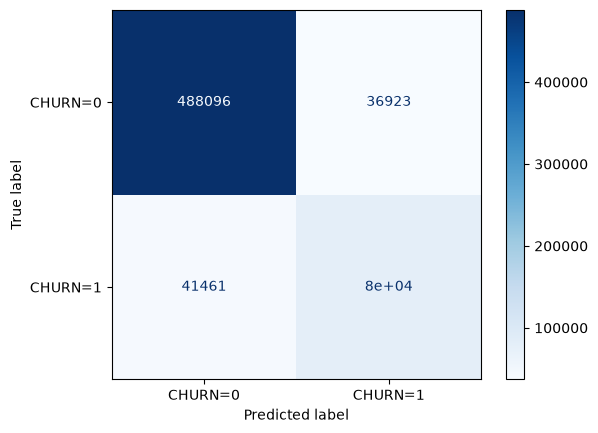

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


mean_test_score = grid.cv_results_['mean_test_score']
std_test_score = grid.cv_results_['std_test_score']
print('Mean test score:', mean_test_score)
print('Std test score:', std_test_score)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['CHURN=0', 'CHURN=1']).plot(cmap='Blues')
plt.show()

### 5.5 Model 3: gradient-boosted trees (XGBoost)
Gradient boosting builds decision trees one after another, and each new tree corrects the errors of the previous ones. Trees capture non-linear effects (such as the tenure peak in Section 4.4), interactions between features and skewed variables without any transformation. XGBoost's histogram method (`tree_method="hist"`) keeps training fast on 1.5M customers.

**Settings.** Every model uses 400 trees, and each tree sees a random 80% of the customers (`subsample`) and of the columns (`colsample_bytree`), which makes the trees more diverse and reduces overfitting. `reg_lambda=1` adds an L2 penalty on the leaf values. We tune three hyperparameters:
- `learning_rate`: how much each tree contributes. Smaller steps need more trees but usually generalise better.
- `max_depth`: the depth of each tree, i.e. how complex the interactions it can model.
- `min_child_weight`: the minimum amount of data in a leaf. Larger values forbid splits that rest on very few customers.

**Validation on one fold.** Each fit takes 1–2 minutes, so a 5-fold search would take five times as long. Instead, we hold out one stratified validation fold (12.5% of the training set, about 188,000 customers; `PredefinedSplit`), which is large enough for a stable estimate. The grid in the code is narrowed to the best region of our first, wider search (the values in the comments: learning rate 0.05 or 0.1, depth 4, 6 or 8, min_child_weight 1 or 10). That search selected **learning rate 0.05, depth 8 and min_child_weight 10**, with a validation ROC-AUC of **0.9307**.

**Test result.** With `refit=True`, the best setting is retrained on the whole training set and evaluated on the test customers from its predicted probabilities: **test ROC-AUC 0.9314**. This is very close to the validation score, so there is no overfitting, and it is the best of the three models.

*The first lines of the cell replace the characters `[`, `]`, `<` and `>` in column names, which XGBoost does not accept (some package names contain them).*

In [ ]:
import re
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, PredefinedSplit, train_test_split

X_train.columns = [re.sub(r"[\[\]<>]", "_", c) for c in X_train.columns] # XGBoost rejects symbols in column names
X_test.columns = X_train.columns

# Hold out a validation fold
_, val_idx = train_test_split(np.arange(len(X_train)), test_size=0.125, stratify=y_train, random_state=RANDOM_STATE)
test_fold = np.full(len(X_train), -1)   # -1 = always train
test_fold[val_idx] = 0                  #  0 = validation fold

param_grid = {
  "max_depth": [4, 6, 8],
  "learning_rate": [0.05, 0.1],
  "min_child_weight":[1, 10],
}

gs = GridSearchCV(
  xgb.XGBClassifier(n_estimators=400, subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, tree_method="hist", random_state=RANDOM_STATE),
  param_grid,
  scoring="roc_auc",
  cv=PredefinedSplit(test_fold),
  refit=True,
  verbose=2,
)
gs.fit(X_train, y_train)

print("Best params: ", gs.best_params_)
print(f"Best val ROC-AUC: {gs.best_score_}")

%time proba = gs.best_estimator_.predict_proba(X_test)[:, 1]
print(f"Test ROC-AUC: {roc_auc_score(y_test, proba)}")

Fitting 1 folds for each of 12 candidates, totalling 12 fits
[CV] END learning_rate=0.05, max_depth=4, min_child_weight=1; total time=  12.5s
[CV] END learning_rate=0.05, max_depth=4, min_child_weight=10; total time=  13.6s
[CV] END learning_rate=0.05, max_depth=6, min_child_weight=1; total time=  17.4s
[CV] END learning_rate=0.05, max_depth=6, min_child_weight=10; total time=  17.4s
[CV] END learning_rate=0.05, max_depth=8, min_child_weight=1; total time=  19.4s
[CV] END learning_rate=0.05, max_depth=8, min_child_weight=10; total time=  18.6s
[CV] END .learning_rate=0.1, max_depth=4, min_child_weight=1; total time=  11.5s
[CV] END learning_rate=0.1, max_depth=4, min_child_weight=10; total time=  11.2s
[CV] END .learning_rate=0.1, max_depth=6, min_child_weight=1; total time=  15.6s
[CV] END learning_rate=0.1, max_depth=6, min_child_weight=10; total time=  14.3s
[CV] END .learning_rate=0.1, max_depth=8, min_child_weight=1; total time=  18.3s
[CV] END learning_rate=0.1, max_depth=8, min_

Mean test score: [0.92959194 0.92961435 0.92978924 0.92979731 0.92976048 0.92979212
 0.92971199 0.92970967 0.92971846 0.92973436 0.92941707 0.92954634]
Std test score: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


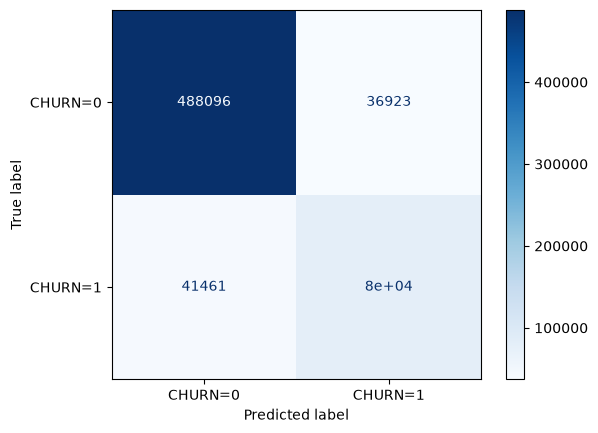

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


mean_test_score = gs.cv_results_['mean_test_score']
std_test_score = gs.cv_results_['std_test_score']
print('Mean test score:', mean_test_score)
print('Std test score:', std_test_score)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['CHURN=0', 'CHURN=1']).plot(cmap='Blues')
plt.show()

## 6. Results Analysis & Conclusion

### 6.1 Baselines: how well can we find churners without ML?
To judge our model fairly, we compare it with two simple strategies:
- **Random targeting:** contact customers at random (no information at all).
- **Simple business rule:** contact the *least active* customers first (lowest `REGULARITY` = number of times the customer was active in 90 days).

Our ML model is only useful if it clearly beats both.

Neither strategy has anything to learn from the data, so we evaluate them on all 2,154,048 customers. Their scores are directly comparable with the test scores of the ML models in Section 5, because the test set is a random, stratified 30% sample of the same customers. For example, on the test set alone the activity rule scores the same ROC-AUC (0.890) as on all customers. The rule's ROC-AUC uses the score −`REGULARITY` and the true `CHURN` labels: it is the probability that a randomly chosen churner was less active than a randomly chosen customer who stayed.

ach strategy gives every customer a score, and ROC-AUC compares that score with the true CHURN labels. Random targeting uses a random number per customer (with a fixed seed, 42, so the result is reproducible). The rule uses REGULARITY, so the least active customers get the highest risk score.

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score

y = df["CHURN"]

# Baseline 1: random targeting (a random score for every customer)
rng = np.random.default_rng(42)
score_random = rng.random(len(df))

# Baseline 2: simple rule (the less active, the higher the risk)
score_rule = -df["REGULARITY"]

print("AUC - random:", round(roc_auc_score(y, score_random), 3))
print("AUC - rule  :", round(roc_auc_score(y, score_rule), 3))

AUC - random: 0.499
AUC - rule  : 0.89


**Result.** Random targeting scores 0.499, as expected for a score with no information (0.5). The activity rule alone reaches **0.89**: churn is defined by 90 days of inactivity, so recent activity is already a strong signal, which makes this rule a demanding baseline. Our models improve on it: about 0.927 for logistic regression and **0.931 for XGBoost** on the test set (Section 5).

**Reaching churners with a limited budget.** ROC-AUC summarises the whole ranking, but a campaign only contacts the top of it. `capture_rate` sorts customers from riskiest to safest and returns the share of *all* churners found among the top k%. In the table below:
- Random targeting reaches about k% of the churners when it contacts k% of the customers (5.0, 10.0, 19.9, 29.9), as expected.
- The rule reaches **37.0%** of all churners by contacting the 10% least active customers, and **64.3%** by contacting 20%. This is more than three times better than random targeting for the same number of contacts.

In [ ]:
def capture_rate(y_true, score, top_frac):
    """Share of ALL churners reached if we contact the top_frac riskiest customers."""
    n_top = int(len(score) * top_frac)
    order = np.argsort(-np.asarray(score), kind="stable")  # riskiest first
    return y_true.to_numpy()[order[:n_top]].sum() / y_true.sum()

fracs = [0.05, 0.10, 0.20, 0.30]
gains = pd.DataFrame({
    "contacted": [f"top {int(f*100)}%" for f in fracs],
    "random (% of churners reached)": [round(100 * capture_rate(y, score_random, f), 1) for f in fracs],
    "rule (% of churners reached)":   [round(100 * capture_rate(y, score_rule, f), 1) for f in fracs],
})
gains

,contacted,random (% of churners reached),rule (% of churners reached)
0,top 5%,5.0,18.8
1,top 10%,10.0,37.0
2,top 20%,19.9,64.3
3,top 30%,29.9,81.3


### 6.2 Business impact: is a targeted campaign worth the money?
We simulate a retention campaign: Expresso sends an offer to the top-k% riskiest customers, as ranked by each strategy. The simulation runs on all 2,154,048 customers.

**Assumptions** (amounts in FCFA, the currency used in package names such as "All-net 500F"; 1 € = 655.957 FCFA; all easy to change):
- **Value of a saved customer:** the median monthly revenue of churners with recorded revenue (826 FCFA, printed below) × 3 months, assuming a saved customer stays at least 3 more months.
- **Offer cost:** 200 FCFA per contacted customer (for example, a free 200F daily bundle).
- **Success rate:** 20% of the contacted churners decide to stay.

**Net benefit** = churners reached × success rate × value of a saved customer − customers contacted × offer cost.

An offer sent to a customer who would have stayed anyway costs money and brings nothing back. The net benefit therefore rewards rankings that put the real churners first.

The cell below computes the value of a saved customer: 826 × 3 = **2,478 FCFA** (about €3.8).

**What this means for a campaign.** With a 20% success rate, every churner we contact is worth on average 0.20 × 2,478 ≈ 496 FCFA, while every offer costs 200 FCFA. A campaign therefore pays off only if more than 200 / 496 ≈ **40% of the contacted customers are real churners**. Random targeting can never reach this, because only 18.75% of customers churn. A good ranking can, because it concentrates the churners at the top of the list.

In [ ]:
# Business assumptions (amounts in FCFA)
MONTHLY_REVENUE = df.loc[df["CHURN"] == 1, "REVENUE"].median()  # typical churner
MONTHS_KEPT     = 3      # a saved customer stays at least 3 more months
OFFER_COST      = 200    # cost of one retention offer
SUCCESS_RATE    = 0.20   # share of contacted churners who decide to stay

VALUE_SAVED = MONTHLY_REVENUE * MONTHS_KEPT
print("Typical monthly revenue of a churner:", MONTHLY_REVENUE, "FCFA")
print("Value of one saved customer:", VALUE_SAVED, "FCFA")

Typical monthly revenue of a churner: 826.0 FCFA
Value of one saved customer: 2478.0 FCFA


`net_benefit` turns a ranking into money. It counts the churners reached among the top k% (with `capture_rate`), multiplies them by the success rate and the value of a saved customer, and subtracts the cost of every offer sent. The table shows the result in million FCFA for each share of customers contacted:
- **Random targeting loses money at every level**, about 2.3M FCFA for every extra 1% of customers contacted. Only 18.75% of its contacts are churners, far below the ~40% needed to break even.
- **Sending the offer to everyone loses 230.6M FCFA (≈ €352K)**, the same for both strategies, since everyone is contacted. Without targeting, retention does not pay.
- **The activity rule makes money.** Among the levels tested, the best is to contact the 20% least active customers, a gain of **42.6M FCFA (≈ €65K) per campaign**. Beyond that the gain falls (33.5M at 30%): the extra customers are less and less likely to churn, so each new offer costs more than it brings back.

Targeting is what makes retention profitable, and a better ranking turns directly into more money.

With our final XGBoost model, the same simulation on the test set (scaled up to all customers) gives a best gain of about 55.7M FCFA (≈ €85K) by contacting the riskiest 22%, about 13–14M FCFA more per campaign than the rule.

In [ ]:
def net_benefit(y_true, score, top_frac):
    """Net benefit (FCFA) of sending the offer to the top_frac riskiest customers."""
    contacted = int(len(score) * top_frac)
    churners_reached = capture_rate(y_true, score, top_frac) * y_true.sum()
    revenue_saved = churners_reached * SUCCESS_RATE * VALUE_SAVED
    return revenue_saved - contacted * OFFER_COST

fracs_all = [0.05, 0.10, 0.20, 0.30, 1.00]
impact = pd.DataFrame({
    "contacted": [f"top {int(f*100)}%" for f in fracs_all],
    "random (million FCFA)": [round(net_benefit(y, score_random, f) / 1e6, 1) for f in fracs_all],
    "rule (million FCFA)":   [round(net_benefit(y, score_rule, f) / 1e6, 1) for f in fracs_all],
})
impact

,contacted,random (million FCFA),rule (million FCFA)
0,top 5%,-11.6,16.2
1,top 10%,-23.2,31.1
2,top 20%,-46.2,42.6
3,top 30%,-69.4,33.5
4,top 100%,-230.6,-230.6


### 6.3 Sensitivity: how much do the results depend on our assumptions?
The success rate and the offer cost are guesses, so we recompute the rule's net benefit when contacting the 20% least active customers, for success rates of 10%, 20% and 30% and offer costs of 100, 200 and 500 FCFA (million FCFA, all customers).

The table below shows that:
- **The offer cost matters most.** With a 100 FCFA offer, the campaign is profitable even if only 10% of the contacted churners stay (+21.3M FCFA). With a 500 FCFA offer it loses money at every success rate we tested, even at 30% (−22.3M).
- **Our central assumption is fragile.** At 200 FCFA and a 20% success rate the gain is 42.6M FCFA, but if only 10% of the churners respond, it turns into a loss (−21.8M).
- **The break-even rule from Section 6.2 explains this.** A campaign pays off only when success rate × value of a saved customer × share of churners among the contacted customers is larger than the cost of one offer.

In practice, Expresso should keep offers cheap and measure the real success rate on a small group (an A/B test) before a full rollout.

In [ ]:
# How does the rule's net benefit (top 20%) change if our assumptions change?
TOP = 0.20
contacted = int(len(y) * TOP)
reached = capture_rate(y, score_rule, TOP) * y.sum()

rows = []
for sr in [0.10, 0.20, 0.30]:
    row = {"success rate": f"{int(sr*100)}%"}
    for cost in [100, 200, 500]:
        row[f"offer {cost} FCFA"] = round((reached * sr * VALUE_SAVED - contacted * cost) / 1e6, 1)
    rows.append(row)
sensitivity = pd.DataFrame(rows)
sensitivity

,success rate,offer 100 FCFA,offer 200 FCFA,offer 500 FCFA
0,10%,21.3,-21.8,-151.0
1,20%,85.6,42.6,-86.7
2,30%,150.0,106.9,-22.3


**How much is a churner really worth?** The campaign above values every saved customer at the median revenue of churners *with recorded revenue*. The cell below compares stayers and churners: the median monthly revenue (among customers with recorded revenue) and the share of customers with no recorded revenue at all.

In [ ]:
revenue_median = df.groupby("CHURN")["REVENUE"].median()
no_revenue = df["REVENUE"].isna().groupby(df["CHURN"]).mean() * 100
print("Median monthly revenue (stayed / churned):", revenue_median[0], "/", revenue_median[1])
print("% with no recorded revenue (stayed / churned):", round(no_revenue[0], 1), "/", round(no_revenue[1], 1))

Median monthly revenue (stayed / churned): 3200.0 / 826.0
% with no recorded revenue (stayed / churned): 22.8 / 80.9


### 6.4 Findings
1. **A simple rule is already strong, and our models beat it.** Ranking customers by activity (`REGULARITY`) alone gives ROC-AUC = 0.89. On the test set, logistic regression reaches about 0.927, KNN about 0.928 and XGBoost 0.931.
2. **Churners are low-value customers.** Among customers with recorded revenue, the median monthly revenue is 826 FCFA for churners vs 3,200 FCFA for customers who stay. Each saved customer is worth little, so retention offers must be cheap.
3. **Targeting is what makes retention profitable.** Sending offers to everyone loses 230.6M FCFA, and random targeting always loses money, while the rule earns up to 42.6M FCFA (≈ €65K) when contacting the top 20%.
4. **The result depends on the offer design.** With 100 FCFA offers the campaign is profitable even at a 10% success rate; with 500 FCFA offers it loses money at every success rate we tested.
5. **Many churners are already silent.** 80.9% of churners have no recorded revenue, vs 22.8% of customers who stay. They are easy to detect but may be too late to save.
6. **Remarks on our ML experiments.**
   - All three models land close together (0.926–0.931 in validation), so the ranking quality seems limited by the information in the features more than by the choice of model.
   - Regularisation does not matter for logistic regression: all penalties are within 0.00002 of each other, because with 1.5M customers and a few dozen features there is no overfitting to control.
   - XGBoost gains a little over the linear model because trees can capture non-linear effects such as the tenure peak (Section 4.4).
   - KNN is accurate but impractical: about 12 minutes to score the test set, and it must keep all training customers in memory.
   - An early version of our evaluation computed ROC-AUC from 0/1 predictions instead of probabilities. This collapses it to the balanced accuracy (0.826 for logistic regression, 0.788 for KNN) and made KNN look much worse than it is.
   - Accuracy is a poor yardstick here, since a model that always predicts "stays" is already 81% accurate.
      - **ROC-AUC must be computed from probabilities.** The test cells of logistic regression and KNN pass 0/1 predictions (`predict`) to `roc_auc_score`. This collapses ROC-AUC to the balanced accuracy at the 0.5 threshold (0.826 and 0.788) and makes KNN look much worse on the test set than in cross-validation. Computed from probabilities, both reach about 0.927–0.928, in line with their cross-validated scores.

### 6.5 Using the model in real life, and its limits
**How Expresso could use it**
1. **Score** all active customers regularly, for example every month.
2. **Rank** them by churn probability and contact as many as the budget allows, near the share where the net benefit peaks (around 20%).
3. **Send a cheap offer** and **A/B-test** it on a small group to measure the real success rate.
4. **Retrain** the model on new data, since customer behaviour and offers change over time.

**Limitations**
- **Timing.** Most churners are already silent when we score them. A real system must flag customers *before* they go quiet, while an offer can still change their mind.
- **Undocumented time windows.** The data does not say over which period each feature was measured, relative to the 90 days that define churn. If they overlap, part of the signal describes churn that is already happening, and real-world performance would be lower than our test score.
- **Business assumptions.** Customer value, offer cost and success rate are estimates (Section 6.3). Expresso should replace them with data from its own campaigns.
- **Value is ignored.** The model ranks customers by churn probability, not by value. Since churners are mostly low-revenue customers, combining the probability with each customer's revenue would focus the offers on the customers worth saving.
- **One snapshot.** We have a single labelled period, so we cannot check how stable the model is over time.

### 6.6 Conclusion
**The problem (Section 1).** Expresso loses prepaid customers silently and needs to know, early, whom to target with retention offers, without wasting offers on customers who would stay anyway.

**What we did.** We cleaned and encoded 2.15M customer records (Section 3), explored them with Seaborn (Section 4), and compared logistic regression, KNN and XGBoost with stratified validation and ROC-AUC (Section 5).

**Does our model solve the problem?** Yes, as a ranking tool. The final model, XGBoost, reaches a test ROC-AUC of **0.931** on customers it has never seen, above the activity rule (0.89) and far above random targeting (0.50). A campaign aimed at the riskiest customers reaches most churners while contacting only a small part of the customer base.

**Can we estimate its impact?** Under our assumptions (a 200 FCFA offer, a 20% success rate, a saved customer worth 2,478 FCFA), targeting the riskiest 20% with the simple activity rule already earns **42.6M FCFA (≈ €65K) per campaign**, while contacting everyone loses 230.6M FCFA. The gain depends strongly on the offer cost and the success rate (Section 6.3), so these figures should be confirmed with a pilot campaign.In a separate check on the test set, ranking customers with XGBoost instead of the rule reaches 70.9% of churners at the top 20% (vs 64.3%) and raises the best gain to about **55.7M FCFA (≈ €85K)**, roughly 13M FCFA more per campaign.

**What matters most in practice.** Targeting, cheap offers and early detection decide whether retention pays. A simple activity rule already captures much of the signal; the model adds a measurable improvement on top of it.